In [8]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

df_A_oct = pd.read_excel("MACHINE_A_OCTOBER_FINAL.xlsx", header=1)
df_B_oct = pd.read_excel("MACHINE_B_OCTOBER_FINAL.xlsx", header=0)
df_A_nov = pd.read_excel("MACHINE_A_NOVEMBER_FINAL.xlsx", header=1)
df_B_nov = pd.read_excel("MACHINE_B_NOVEMBER_FINAL.xlsx", header=1)

print("A Oct:", df_A_oct.shape)
print("B Oct:", df_B_oct.shape)
print("A Nov:", df_A_nov.shape)
print("B Nov:", df_B_nov.shape)

Saving MACHINE_B_NOVEMBER_FINAL.xlsx to MACHINE_B_NOVEMBER_FINAL (1).xlsx
Saving MACHINE_B_OCTOBER_FINAL.xlsx to MACHINE_B_OCTOBER_FINAL (1).xlsx
Saving MACHINE_A_NOVEMBER_FINAL.xlsx to MACHINE_A_NOVEMBER_FINAL (1).xlsx
Saving MACHINE_A_OCTOBER_FINAL.xlsx to MACHINE_A_OCTOBER_FINAL (1).xlsx
A Oct: (401, 12)
B Oct: (397, 12)
A Nov: (462, 12)
B Nov: (351, 12)


In [12]:
import numpy as np
import pandas as pd

def analyze_sales_categories(df):
    # These are the standard names we will use inside this function
    date_col      = "Transaction Date"
    status_col    = "Status"
    product_code  = "Product Code.1"
    product_name  = "Product Name"
    category_col  = "Category"

    df = df.copy()

    # Clean date
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col])

    # Keep successful transactions only
    df = df[df[status_col].astype(str).str.lower().eq("successful")]

    # Clean strings
    df["Product Code"] = df[product_code].astype(str).str.strip()
    df["Product Name"] = df[product_name].astype(str).str.strip()
    df["Category"]     = df[category_col].astype(str).str.strip()
    df["Date"]         = df[date_col].dt.date

    # Best selling categories
    category_counts = (
        df.groupby("Category")
          .size()
          .sort_values(ascending=False)
          .rename("Transactions")
          .reset_index()
    )

    # Worst category
    worst_category = category_counts.tail(1)

    # Top 2 products within each category
    prod_cat_counts = (
        df.groupby(["Category", "Product Code", "Product Name"])
          .size()
          .rename("Transactions")
          .reset_index()
          .sort_values(["Category", "Transactions"], ascending=[True, False])
    )

    top2_each_category = (
        prod_cat_counts
        .groupby("Category", as_index=False, group_keys=False)
        .head(2)
        .reset_index(drop=True)
    )

    # Least selling items in each category
    min_per_cat = (
        prod_cat_counts.groupby("Category")["Transactions"]
        .min()
        .rename("MinTransactions")
        .reset_index()
    )

    least_each_category = (
        prod_cat_counts.merge(min_per_cat, on="Category", how="left")
        .query("Transactions == MinTransactions")
        .drop(columns=["MinTransactions"])
        .sort_values(["Category", "Product Code"])
        .reset_index(drop=True)
    )

    # Fastest selling product
    if df["Date"].nunique() < 2:
        prod_speed = pd.DataFrame(
            columns=["Product Code", "Product Name", "TotalSold", "FirstSale", "LastSale", "DaysActive", "VelocityPerDay"]
        )
        fastest_product = prod_speed.head(0)
    else:
        prod_speed = (
            df.groupby(["Product Code", "Product Name"])
              .agg(
                  TotalSold=("Product Code", "size"),
                  FirstSale=(date_col, "min"),
                  LastSale=(date_col, "max")
              )
              .reset_index()
        )

        prod_speed["DaysActive"] = (
            (prod_speed["LastSale"] - prod_speed["FirstSale"]).dt.total_seconds() / 86400.0
        ).fillna(0)

        prod_speed["VelocityPerDay"] = prod_speed["TotalSold"] / (prod_speed["DaysActive"] + 1)

        fastest_product = (
            prod_speed.sort_values("VelocityPerDay", ascending=False)
                      .head(1)
                      .reset_index(drop=True)
        )

    return category_counts, top2_each_category, least_each_category, worst_category, fastest_product, prod_speed

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

#Best Selling Categories Graph
def plot_best_selling_categories(category_counts, label):
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(data=category_counts, x='Category', y='Transactions', hue='Category', palette="magma", legend=False)

    ax.bar_label(ax.containers[0], padding=3, fontweight='bold')

    plt.title(f'Total Sales by Category ({label})')
    plt.xticks(rotation=45)
    plt.show()

#Fastest Selling Products Graph
def plot_velocity_scatter(velocity_df, label):
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    sns.scatterplot(
        data=velocity_df,
        x='TotalSold',
        y='VelocityPerDay',
        size='TotalSold',
        sizes=(50, 600),
        hue='VelocityPerDay',
        palette="viridis",
        legend=None,
        alpha=0.6
    )

    top_items = velocity_df.sort_values("VelocityPerDay", ascending=False).head(3)
    for _, row in top_items.iterrows():
        plt.text(row['TotalSold'] + 0.3, row['VelocityPerDay'], row['Product Name'],
                 fontsize=9, fontweight='bold', color='black')

    plt.title(f'Fasting Selling Products ({label})', fontsize=14)
    plt.xlabel('Total Units Sold (Volume)')
    plt.ylabel('Daily Sales Speed (Velocity)')
    plt.tight_layout()
    plt.show()


FILE: MACHINE A OCTOBER

Best Selling Categories:
| Category       |   Transactions |
|:---------------|---------------:|
| Non vegetarian |            221 |
| Beverage       |             82 |
| Vegetarian     |             65 |
| Bakery         |             16 |
| Gluten-free    |             14 |
| Vegan          |              3 |



/tmp/ipython-input-2377927000.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce")


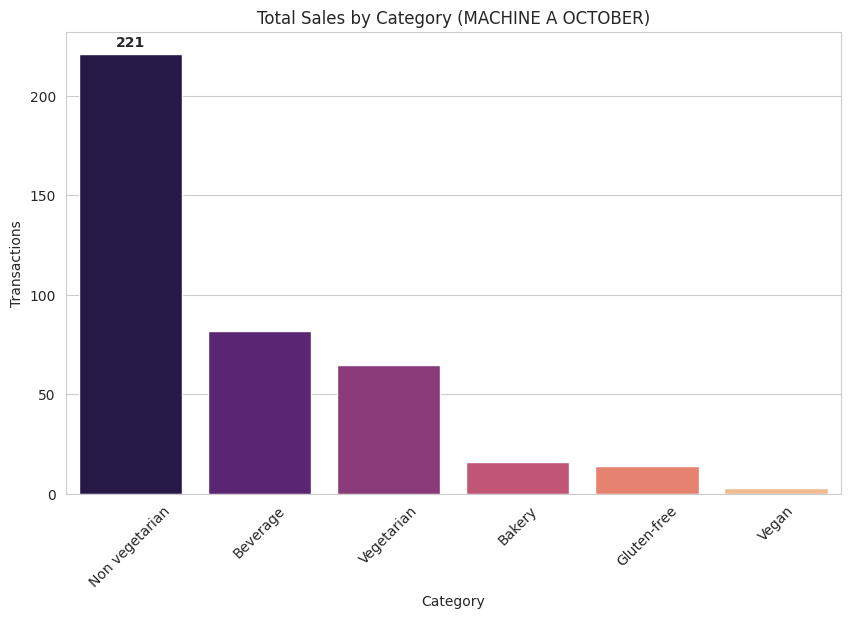


Worst Category:
| Category   |   Transactions |
|:-----------|---------------:|
| Vegan      |              3 |

Top 2 Products Within Each Category:
| Category       | Product Code   | Product Name                     |   Transactions |
|:---------------|:---------------|:---------------------------------|---------------:|
| Bakery         | UMMIV9         | Tomato Mozzarella Pesto Sandwich |              9 |
| Bakery         | UMMIV1         | Falafel Wrap                     |              7 |
| Beverage       | UMMIJ5         | Watermelon Juice Fresh           |             17 |
| Beverage       | UMMIJ4         | Pomegranate Juice                |             16 |
| Gluten-free    | UMMIF1         | Banana Berry Acai Bowl           |              7 |
| Gluten-free    | UMMIF2         | Tropical Açaí Bowl               |              5 |
| Non vegetarian | UMMIR27        | Steamed Rice with Butter Chicken |             23 |
| Non vegetarian | UMMIS3         | Chicken & Yuzu Poke B

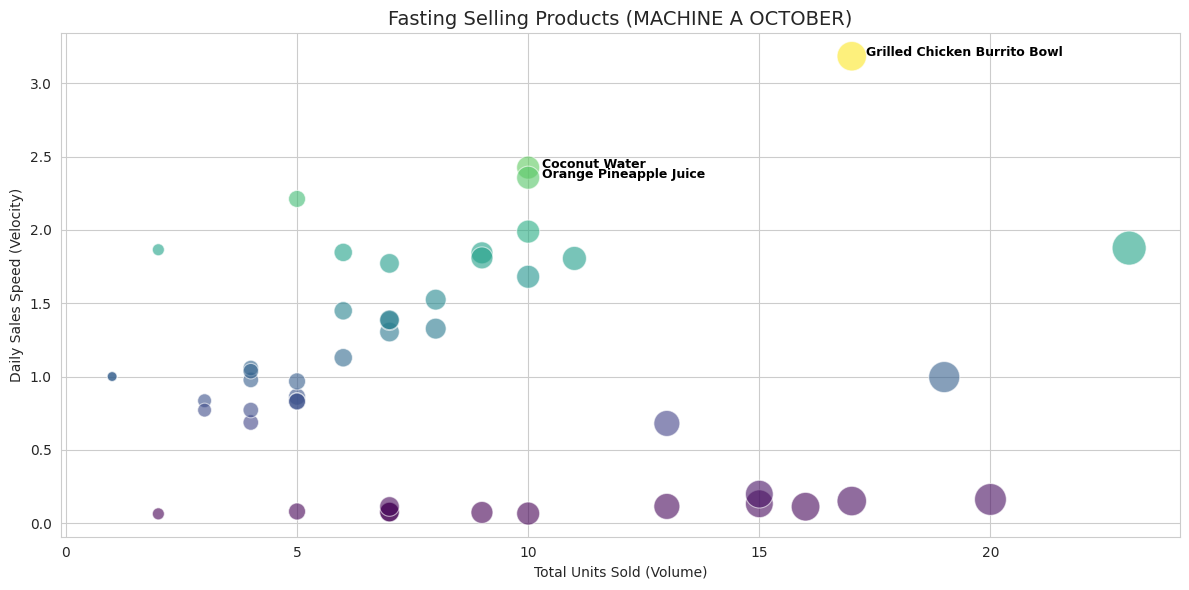


FILE: MACHINE B OCTOBER

Best Selling Categories:
| Category       |   Transactions |
|:---------------|---------------:|
| Non vegetarian |            211 |
| Vegetarian     |             88 |
| Beverage       |             81 |
| Bakery         |             14 |
| Vegan          |              3 |



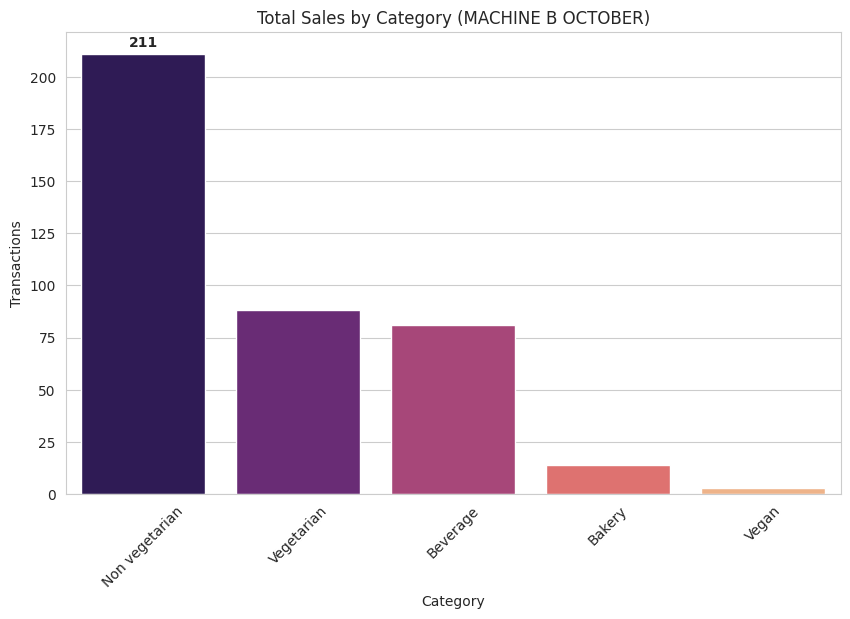


Worst Category:
| Category   |   Transactions |
|:-----------|---------------:|
| Vegan      |              3 |

Top 2 Products Within Each Category:
| Category       | Product Code   | Product Name                     |   Transactions |
|:---------------|:---------------|:---------------------------------|---------------:|
| Bakery         | UMMIV9         | Tomato Mozzarella Pesto Sandwich |             14 |
| Beverage       | UMMIJ4         | Pomegranate Juice                |             27 |
| Beverage       | UMMIJ5         | Watermelon Juice Fresh           |             17 |
| Non vegetarian | UMMIS3         | Chicken & Yuzu Poke Bowl         |             25 |
| Non vegetarian | UMMIV4         | Chicken Caesar Wrap              |             18 |
| Vegan          | UMMIG2         | Vegan Burrito Bowl               |              3 |
| Vegetarian     | UMMIF1         | Banana Berry Acai Bowl           |             11 |
| Vegetarian     | UMMIS12        | Feta & Nut Salad     

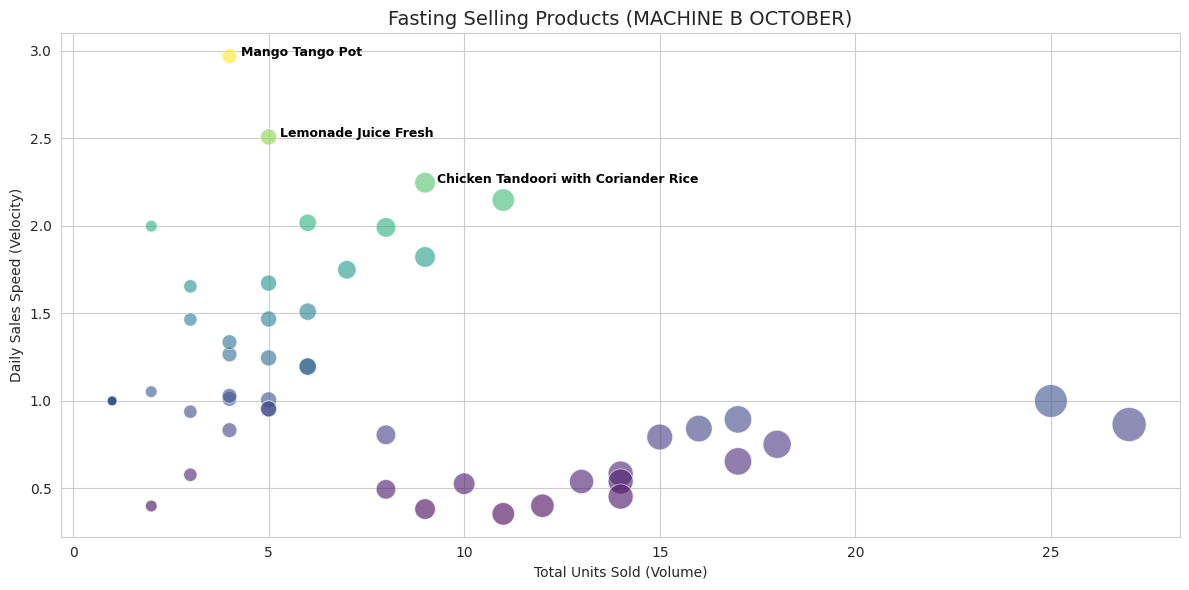


FILE: MACHINE A NOVEMBER

Best Selling Categories:
| Category       |   Transactions |
|:---------------|---------------:|
| Non vegetarian |            217 |
| Beverage       |            110 |
| Vegetarian     |            103 |
| Bakery         |             10 |
| Gluten - Free  |              9 |
| Vegeterian     |              9 |
| Vegan          |              4 |



/tmp/ipython-input-2377927000.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce")


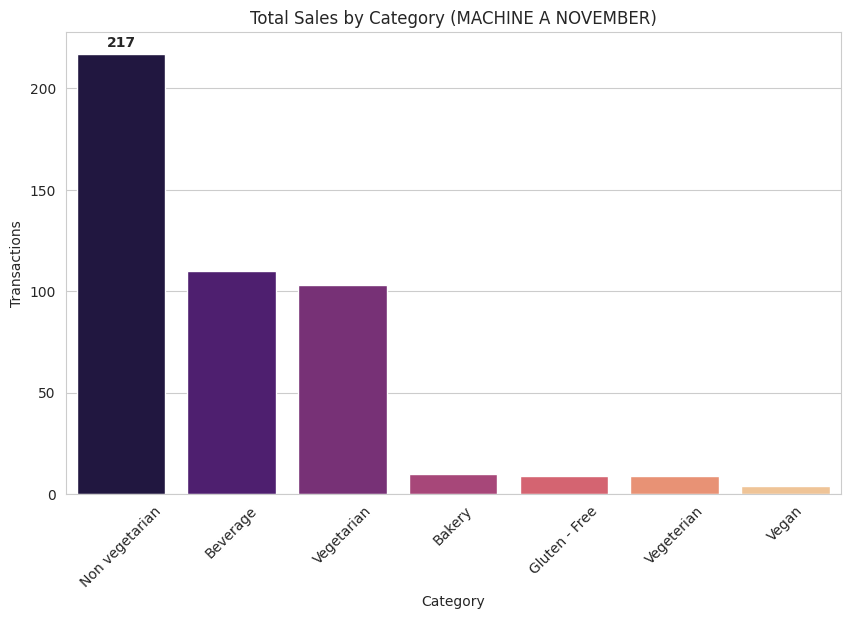


Worst Category:
| Category   |   Transactions |
|:-----------|---------------:|
| Vegan      |              4 |

Top 2 Products Within Each Category:
| Category       | Product Code   | Product Name                       |   Transactions |
|:---------------|:---------------|:-----------------------------------|---------------:|
| Bakery         | UMMIS30        | Labneh and Zaatar in Brown Bread   |              5 |
| Bakery         | UMMIS31        | Cheese Croissant                   |              4 |
| Beverage       | UMMIJ5         | Watermelon Juice Fresh             |             26 |
| Beverage       | UMMIJ2         | Orange Juice Fresh                 |             23 |
| Gluten - Free  | UMMIF1         | Banana Berry Acai Bowl             |              9 |
| Non vegetarian | UMMIG1         | Grilled Chicken Burrito Bowl       |             33 |
| Non vegetarian | UMMIS1         | Pasta & Herb Chicken Salad         |             23 |
| Vegan          | UMMIS4         | Tof

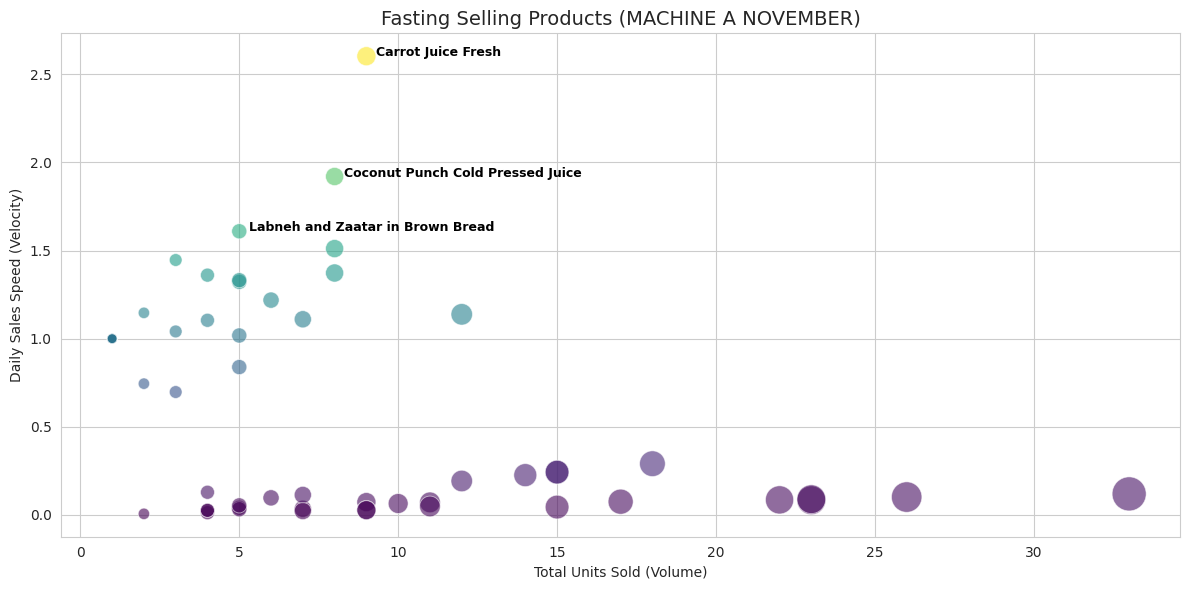


FILE: MACHINE B NOVEMBER

Best Selling Categories:
| Category       |   Transactions |
|:---------------|---------------:|
| Non vegetarian |            160 |
| Vegetarian     |            107 |
| Beverage       |             78 |
| Vegan          |              6 |



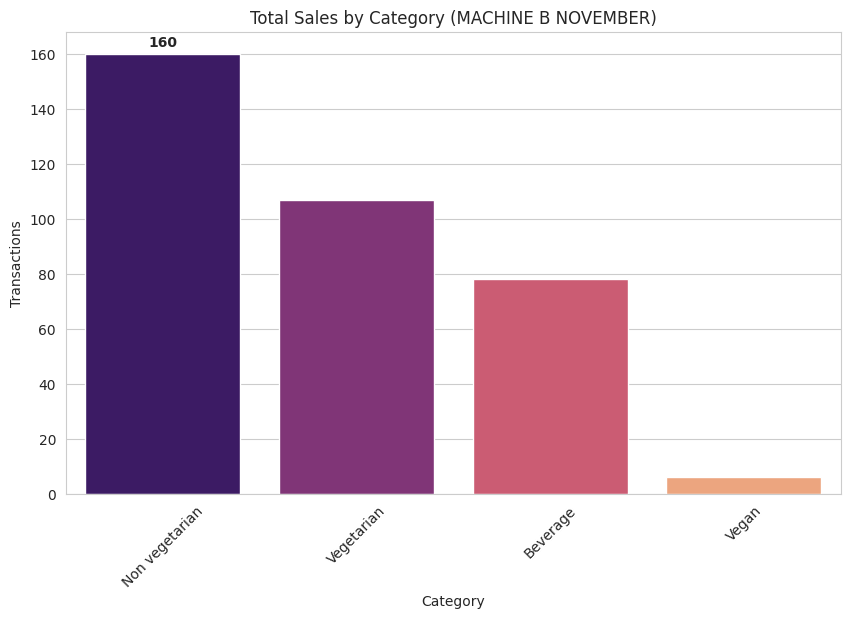


Worst Category:
| Category   |   Transactions |
|:-----------|---------------:|
| Vegan      |              6 |

Top 2 Products Within Each Category:
| Category       | Product Code   | Product Name                 |   Transactions |
|:---------------|:---------------|:-----------------------------|---------------:|
| Beverage       | UMMIJ2         | Orange Juice Fresh           |             19 |
| Beverage       | UMMIJ5         | Watermelon Juice Fresh       |             13 |
| Non vegetarian | UMMIG1         | Grilled Chicken Burrito Bowl |             23 |
| Non vegetarian | UMMIR12        | Chicken Biryani              |             19 |
| Vegan          | UMMIG2         | Vegan Burrito Bowl           |              6 |
| Vegetarian     | UMMIB2         | Berry Sweet Tart Pot         |             14 |
| Vegetarian     | UMMIV1         | Falafel Wrap                 |             14 |

Least Selling Items In Each Category:
| Category       | Product Code   | Product Name      

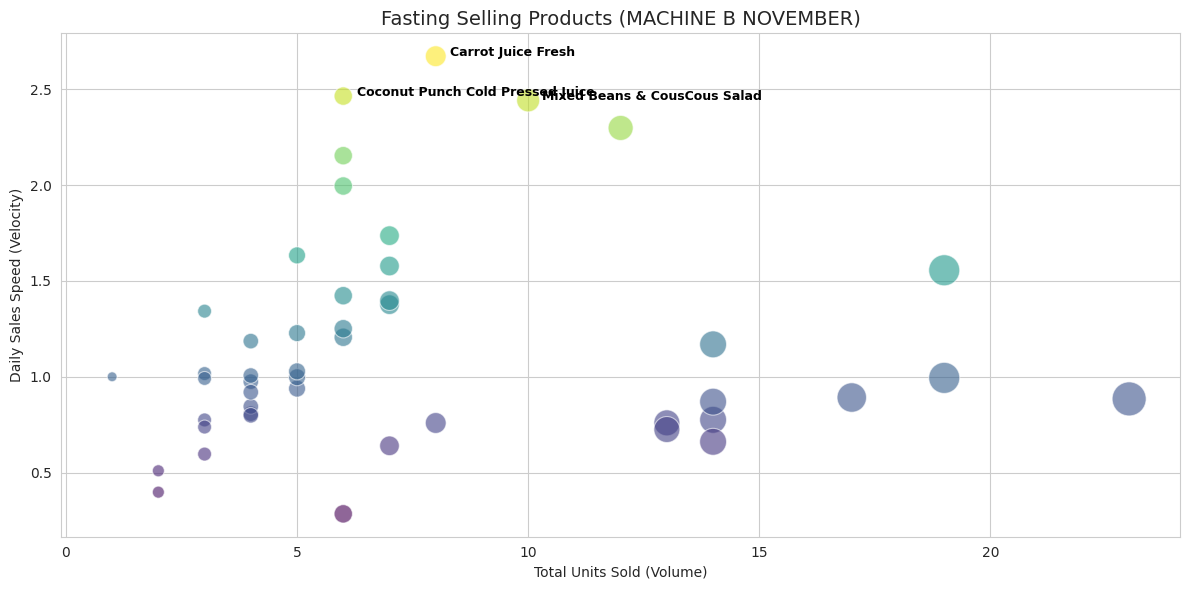

In [15]:
files_dict = {
    "MACHINE A OCTOBER": df_A_oct,
    "MACHINE B OCTOBER": df_B_oct,
    "MACHINE A NOVEMBER": df_A_nov,
    "MACHINE B NOVEMBER": df_B_nov,
}

for label, df in files_dict.items():
    try:
        print("\n" + "="*90)
        print("FILE:", label)

        if 'Product Code' in df.columns and 'Product Code.1' not in df.columns:
            df = df.rename(columns={'Product Code': 'Product Code.1'})

        if 'Categories' in df.columns and 'Category' not in df.columns:
            df = df.rename(columns={'Categories': 'Category'})

        possible_name_cols = ['Product Name', 'Menu']
        for col in possible_name_cols:
            if col in df.columns:
                df = df.rename(columns={col: 'Product Name'})
                break

        category_counts, top2, least_items, worst_cat, fastest, velocity_df = analyze_sales_categories(df)


        print("\nBest Selling Categories:")
        print(category_counts.to_markdown(index=False))
        print()
        plot_best_selling_categories(category_counts, label)
        print("\nWorst Category:")
        print(worst_cat.to_markdown(index=False))

        print("\nTop 2 Products Within Each Category:")
        print(top2.to_markdown(index=False))

        print("\nLeast Selling Items In Each Category:")
        print(least_items.to_markdown(index=False))

        print("\nFastest Selling Product:")
        print(fastest.to_markdown(index=False))
        print()
        plot_velocity_scatter(velocity_df, label)

    except Exception as e:
        print(f"Error while processing {label}: {e}")